In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

In [33]:
mnist_keras = tf.keras.datasets.mnist

(x_train, Y_train), (x_test, y_test) = mnist_keras.load_data()

X_train = x_train[:50000]
y_train = Y_train[:50000]

In [34]:
initializer = tf.keras.initializers.Constant(1)

model = tf.keras.models.Sequential([

  tf.keras.layers.Input((28, 28), name='input'),
  tf.keras.layers.Flatten(),

  tf.keras.layers.Dense(100, name='hidden_1', use_bias=False, kernel_initializer='he_normal'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.ReLU(),

  tf.keras.layers.Dense(100, name='hidden_2', use_bias=False, kernel_initializer='he_normal'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.ReLU(),

  tf.keras.layers.Dense(10, activation='softmax', use_bias=False, name='output', kernel_initializer='he_normal')
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 100)            │        78,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,200 (352.34 KB)

 Trainable params: 89,800 (350.78 KB)

 Non-trainable params: 400 (1.56 KB)

In [35]:
%load_ext tensorboard

tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir='./log/weight_init/',
    histogram_freq=1,  # Registrar histogramas cada epoch
    write_graph=True,  # Registrar el gráfico del modelo
    write_images=True,  # Registrar imágenes
    embeddings_freq=1,  # Registrar proyecciones de embeddings cada epoch
    update_freq='batch'  # Actualizar los registros en cada batch
)

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [36]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [37]:
history = model.fit(X_train,
                          y_train,
                          epochs=50,
                          validation_split=0.2,
                          batch_size=32,
                          callbacks=tensorboard_cb)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8535 - loss: 0.5011 - val_accuracy: 0.9536 - val_loss: 0.1534
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9598 - loss: 0.1355 - val_accuracy: 0.9609 - val_loss: 0.1331
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9716 - loss: 0.0913 - val_accuracy: 0.9664 - val_loss: 0.1120
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9772 - loss: 0.0725 - val_accuracy: 0.9702 - val_loss: 0.1034
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9804 - loss: 0.0601 - val_accuracy: 0.9677 - val_loss: 0.1069
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9802 - loss: 0.0568 - val_accuracy: 0.9685 - val_loss: 0.1105
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9844 - loss: 0.0463 - val_accuracy: 0.9728 - val_loss: 0.1022
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9870 - loss: 0

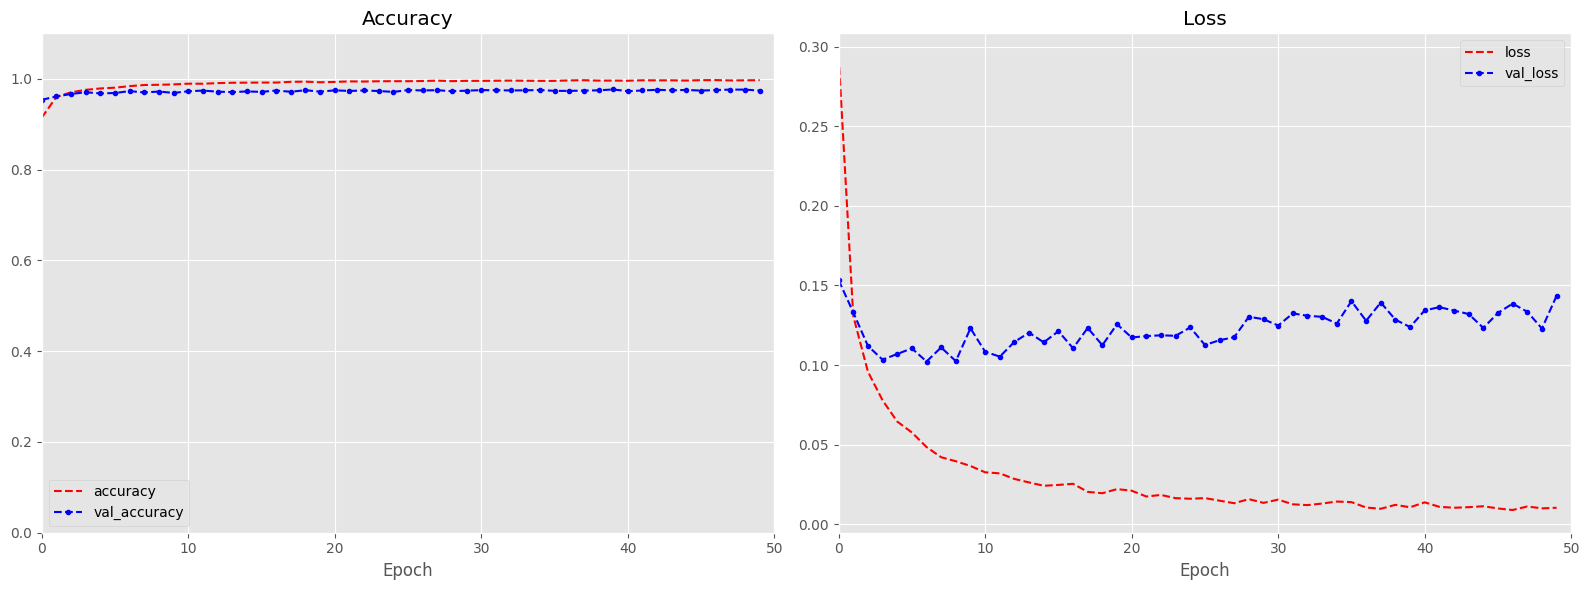

In [38]:
# Convertir el historial a DataFrame
df = pd.DataFrame(history.history)

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Primer subplot: Accuracy
df[['accuracy', 'val_accuracy']].plot(
    ax=axes[0],
    xlim=[0, 50], ylim=[0, 1.1], grid=True,
    xlabel="Epoch", style=["r--", "b--."])
axes[0].set_title('Accuracy')
axes[0].legend(loc="best")

# Segundo subplot: Loss
df[['loss', 'val_loss']].plot(
    ax=axes[1],
    xlim=[0, 50], grid=True,
    xlabel="Epoch", style=["r--", "b--."])
axes[1].set_title('Loss')
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │        50,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,928 (206.75 KB)

 Trainable params: 52,736 (206.00 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.3886 - loss: 1.8856 - val_accuracy: 0.8500 - val_loss: 0.9927 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7307 - loss: 0.9602 - val_accuracy: 0.8820 - val_loss: 0.5902 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7997 - loss: 0.7275 - val_accuracy: 0.8980 - val_loss: 0.4177 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8188 - loss: 0.6356 - val_accuracy: 0.9120 - val_loss: 0.3565 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8518 - loss: 0.5278 - val_accuracy: 0.9150 - val_loss: 0.3257 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8544 - loss: 0.4972 - val_accuracy: 0.9130 - val_loss: 0.3057 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8729 - loss: 0.

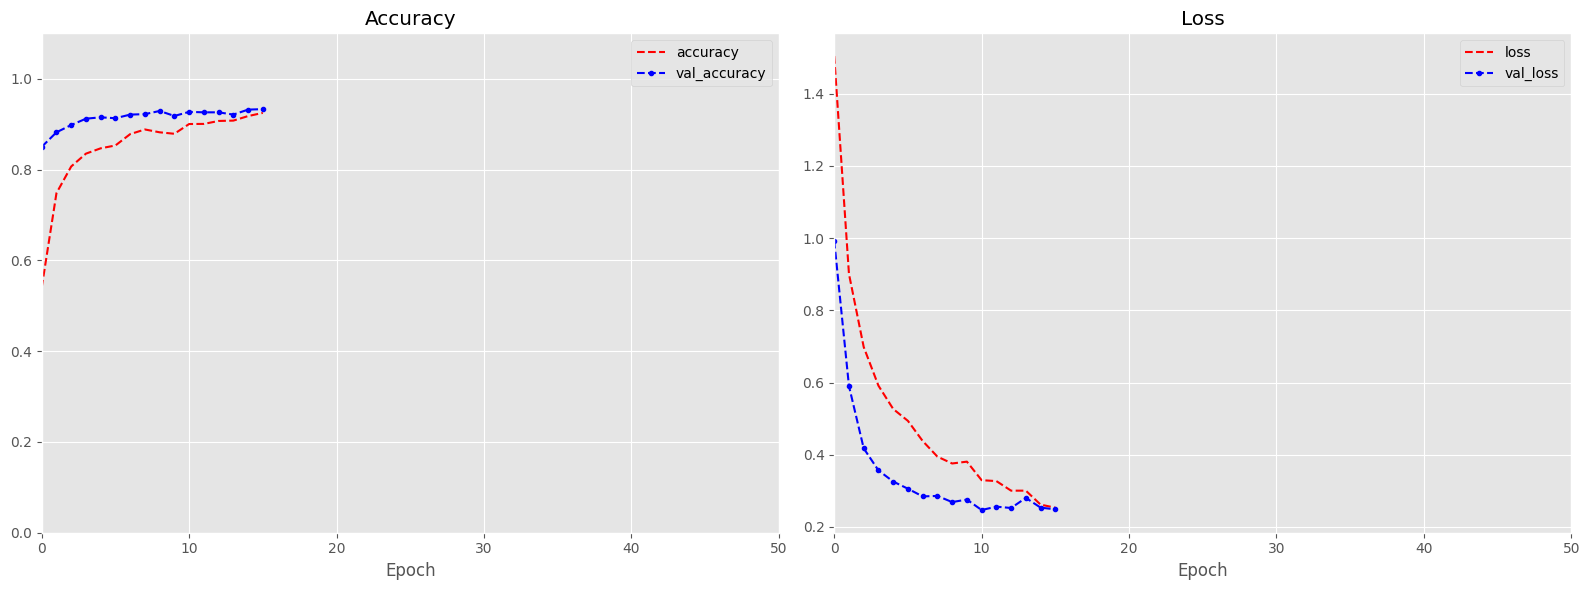

In [27]:
import tensorflow as tf

# Cargar y preparar datos
mnist_keras = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist_keras.load_data()

# CORREGIR: Usar mismo número de ejemplos
X_train = x_train[:5000]
y_train = y_train[:5000]  # ✅ Corregido: mismo tamaño

# Normalizar datos
X_train = X_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Callbacks mejorados
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir='./log/weight_init_improved/',
    histogram_freq=1,
    write_graph=True,
    write_images=True,
    update_freq='epoch'  # Cambiado de 'batch' para mejor rendimiento
)

# Early stopping para prevenir overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate on plateau
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Modelo más apropiado para el tamaño de datos
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((28, 28), name='input'),
    tf.keras.layers.Flatten(),
    
    # Capas más pequeñas para evitar overfitting
    tf.keras.layers.Dense(64, name='hidden_1', use_bias=False, kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.3),  # ✅ Regularización
    
    tf.keras.layers.Dense(32, name='hidden_2', use_bias=False, kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.3),  # ✅ Regularización
    
    tf.keras.layers.Dense(10, activation='softmax', use_bias=False, name='output')
])

model.summary()

# Compilar con regularización L2
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar con callbacks mejorados
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=[tensorboard_cb, early_stopping, lr_scheduler],
    verbose=1
)

# Evaluar en test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Convertir el historial a DataFrame
df = pd.DataFrame(history.history)

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Primer subplot: Accuracy
df[['accuracy', 'val_accuracy']].plot(
    ax=axes[0],
    xlim=[0, 50], ylim=[0, 1.1], grid=True,
    xlabel="Epoch", style=["r--", "b--."])
axes[0].set_title('Accuracy')
axes[0].legend(loc="best")

# Segundo subplot: Loss
df[['loss', 'val_loss']].plot(
    ax=axes[1],
    xlim=[0, 50], grid=True,
    xlabel="Epoch", style=["r--", "b--."])
axes[1].set_title('Loss')
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

In [42]:
%pip install scikeras
import tensorflow as tf
import numpy as np
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

# =====================================================
# 🎯 MEJORES PRÁCTICAS EN REDES NEURONALES
# =====================================================

class NeuralNetworkBestPractices:
    def __init__(self):
        self.model = None
        self.history = None
    
    # 1. ⚙️ OPTIMIZACIÓN DE HIPERPARÁMETROS
    def create_model_for_tuning(self, learning_rate=0.001, dropout_rate=0.3, 
                               units_1=64, units_2=32, l2_reg=0.01):
        """Modelo parametrizado para búsqueda de hiperparámetros"""
        model = tf.keras.Sequential([
            tf.keras.layers.Input((28, 28)),
            tf.keras.layers.Flatten(),
            
            # Capa 1 con regularización L2
            tf.keras.layers.Dense(units_1, 
                                kernel_regularizer=l2(l2_reg),
                                kernel_initializer='he_normal'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(dropout_rate),
            
            # Capa 2 con regularización L2
            tf.keras.layers.Dense(units_2,
                                kernel_regularizer=l2(l2_reg),
                                kernel_initializer='he_normal'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(dropout_rate),
            
            # Salida
            tf.keras.layers.Dense(10, activation='softmax')
        ])
        
        # Optimizador con learning rate personalizado
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
        
        model.compile(optimizer=optimizer,
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
        return model
    
    def hyperparameter_search(self, X_train, y_train):
        """Búsqueda de hiperparámetros con RandomizedSearchCV"""
        
        # Definir espacio de búsqueda
        param_distributions = {
            'learning_rate': [0.001, 0.003, 0.01, 0.03],
            'dropout_rate': [0.2, 0.3, 0.4, 0.5],
            'units_1': [32, 64, 128],
            'units_2': [16, 32, 64],
            'l2_reg': [0.001, 0.01, 0.1],
            'batch_size': [16, 32, 64],
            'epochs': [20]  # Reducido para demo
        }
        
        # Wrapper para scikit-learn
        model = KerasClassifier(build_fn=self.create_model_for_tuning, verbose=0)
        
        # Búsqueda aleatoria
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_distributions,
            n_iter=10,  # Número de combinaciones a probar
            cv=3,       # Cross-validation
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )
        
        print("🔍 Iniciando búsqueda de hiperparámetros...")
        random_search.fit(X_train, y_train)
        
        print(f"✅ Mejores parámetros: {random_search.best_params_}")
        print(f"✅ Mejor score: {random_search.best_score_:.4f}")
        
        return random_search.best_params_
    
    # 2. 📊 BATCH STRATEGIES
    def demonstrate_batch_strategies(self, X_train, y_train):
        """Demostrar diferentes estrategias de batch"""
        
        strategies = {
            'SGD (batch_size=1)': 1,
            'Mini-batch pequeño': 16,
            'Mini-batch medio': 32,
            'Mini-batch grande': 128,
            'Batch completo': len(X_train)
        }
        
        results = {}
        
        for name, batch_size in strategies.items():
            print(f"\n📊 Probando: {name}")
            
            model = self.create_optimized_model()
            
            # Ajustar learning rate según batch size
            if batch_size == 1:
                lr = 0.01  # SGD necesita LR más alto
            elif batch_size <= 32:
                lr = 0.001
            else:
                lr = 0.003  # Batch grande puede usar LR más alto
            
            model.compile(
                optimizer=tf.keras.optimizers.Adam(lr),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )
            
            # Entrenar brevemente para comparar
            history = model.fit(X_train, y_train,
                              batch_size=min(batch_size, len(X_train)),
                              epochs=10,
                              validation_split=0.2,
                              verbose=0)
            
            final_acc = history.history['val_accuracy'][-1]
            results[name] = final_acc
            print(f"   Accuracy final: {final_acc:.4f}")
        
        return results
    
    # 3. 🌊 CONTROL DE GRADIENTES
    def create_gradient_controlled_model(self):
        """Modelo con técnicas para controlar gradientes"""
        
        model = tf.keras.Sequential([
            tf.keras.layers.Input((28, 28)),
            tf.keras.layers.Flatten(),
            
            # Múltiples capas para demostrar gradient clipping
            tf.keras.layers.Dense(128, kernel_initializer='he_normal'),
            tf.keras.layers.BatchNormalization(),  # Ayuda con gradientes
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(0.3),
            
            tf.keras.layers.Dense(64, kernel_initializer='he_normal'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(0.3),
            
            tf.keras.layers.Dense(32, kernel_initializer='he_normal'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(0.3),
            
            tf.keras.layers.Dense(10, activation='softmax')
        ])
        
        # Optimizador con gradient clipping
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=0.001,
            clipnorm=1.0,      # Clip gradientes por norma
            clipvalue=0.5      # Clip gradientes por valor
        )
        
        model.compile(optimizer=optimizer,
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
        
        return model
    
    # 4. 🛡️ REGULARIZACIÓN COMPLETA
    def create_regularized_model(self):
        """Modelo con todas las técnicas de regularización"""
        
        model = tf.keras.Sequential([
            tf.keras.layers.Input((28, 28)),
            tf.keras.layers.Flatten(),
            
            # L1 + L2 + Dropout + BatchNorm
            tf.keras.layers.Dense(128,
                                kernel_regularizer=l1_l2(l1=0.001, l2=0.01),  # L1 + L2
                                kernel_initializer='he_normal'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(0.4),  # Dropout alto
            
            tf.keras.layers.Dense(64,
                                kernel_regularizer=l2(0.01),  # Solo L2
                                kernel_initializer='he_normal'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(0.3),
            
            # Capa de salida sin regularización excesiva
            tf.keras.layers.Dense(10, activation='softmax',
                                kernel_regularizer=l2(0.001))
        ])
        
        return model
    
    # 5. 🚀 OPTIMIZADORES AVANZADOS
    def compare_optimizers(self, X_train, y_train):
        """Comparar diferentes optimizadores"""
        
        optimizers = {
            'Adam': tf.keras.optimizers.Adam(0.001),
            'AdamW': tf.keras.optimizers.AdamW(0.001, weight_decay=0.01),
            'RMSprop': tf.keras.optimizers.RMSprop(0.001),
            'SGD + Momentum': tf.keras.optimizers.SGD(0.01, momentum=0.9),
            'SGD + Nesterov': tf.keras.optimizers.SGD(0.01, momentum=0.9, nesterov=True)
        }
        
        results = {}
        
        for name, optimizer in optimizers.items():
            print(f"\n🚀 Probando optimizador: {name}")
            
            model = self.create_optimized_model()
            model.compile(optimizer=optimizer,
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])
            
            history = model.fit(X_train, y_train,
                              epochs=15,
                              validation_split=0.2,
                              batch_size=32,
                              verbose=0)
            
            final_acc = history.history['val_accuracy'][-1]
            results[name] = final_acc
            print(f"   Accuracy final: {final_acc:.4f}")
        
        return results
    
    # 6. 🎯 INICIALIZACIÓN CORRECTA
    def demonstrate_initializations(self):
        """Demostrar diferentes inicializaciones"""
        
        initializers = {
            'he_normal': 'he_normal',      # Para ReLU
            'glorot_uniform': 'glorot_uniform',  # Para tanh/sigmoid
            'lecun_normal': 'lecun_normal',      # Para SELU
            'random_normal': tf.keras.initializers.RandomNormal(0, 0.02),
            'xavier_uniform': 'glorot_uniform'
        }
        
        models = {}
        
        for name, init in initializers.items():
            model = tf.keras.Sequential([
                tf.keras.layers.Input((28, 28)),
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(64, kernel_initializer=init),
                tf.keras.layers.ReLU(),
                tf.keras.layers.Dense(32, kernel_initializer=init),
                tf.keras.layers.ReLU(),
                tf.keras.layers.Dense(10, activation='softmax', kernel_initializer=init)
            ])
            
            models[name] = model
            print(f"✅ Modelo con {name} creado")
        
        return models
    
    # 7. 📋 CALLBACKS ESENCIALES
    def get_essential_callbacks(self):
        """Callbacks esenciales para cualquier entrenamiento"""
        
        callbacks = [
            # Early Stopping
            EarlyStopping(
                monitor='val_loss',
                patience=7,
                restore_best_weights=True,
                verbose=1,
                min_delta=0.001
            ),
            
            # Reduce Learning Rate
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.3,
                patience=4,
                min_lr=1e-7,
                verbose=1
            ),
            
            # Model Checkpoint
            ModelCheckpoint(
                'best_model.h5',
                monitor='val_accuracy',
                save_best_only=True,
                mode='max',
                verbose=1
            ),
            
            # TensorBoard
            tf.keras.callbacks.TensorBoard(
                log_dir='./logs',
                histogram_freq=1,
                write_graph=True
            )
        ]
        
        return callbacks
    
    # 8. 🏆 MODELO CON TODAS LAS MEJORES PRÁCTICAS
    def create_optimized_model(self):
        """Modelo que implementa TODAS las mejores prácticas"""
        
        model = tf.keras.Sequential([
            tf.keras.layers.Input((28, 28), name='input'),
            tf.keras.layers.Flatten(),
            
            # Capa 1: He initialization + BatchNorm + Dropout + L2
            tf.keras.layers.Dense(64,
                                kernel_initializer='he_normal',
                                kernel_regularizer=l2(0.01),
                                use_bias=False,  # BatchNorm hace el bias innecesario
                                name='dense1'),
            tf.keras.layers.BatchNormalization(name='bn1'),
            tf.keras.layers.ReLU(name='relu1'),
            tf.keras.layers.Dropout(0.3, name='dropout1'),
            
            # Capa 2: Mismas técnicas
            tf.keras.layers.Dense(32,
                                kernel_initializer='he_normal',
                                kernel_regularizer=l2(0.01),
                                use_bias=False,
                                name='dense2'),
            tf.keras.layers.BatchNormalization(name='bn2'),
            tf.keras.layers.ReLU(name='relu2'),
            tf.keras.layers.Dropout(0.2, name='dropout2'),  # Menos dropout en capas más profundas
            
            # Salida: Sin regularización excesiva
            tf.keras.layers.Dense(10,
                                activation='softmax',
                                kernel_initializer='glorot_uniform',  # Para softmax
                                name='output')
        ])
        
        return model
    
    # 9. 🎯 PIPELINE COMPLETO DE ENTRENAMIENTO
    def full_training_pipeline(self, X_train, y_train, X_test, y_test):
        """Pipeline completo con todas las mejores prácticas"""
        
        print("🚀 Iniciando pipeline completo de entrenamiento...")
        
        # 1. Crear modelo optimizado
        model = self.create_optimized_model()
        
        # 2. Optimizador con gradient clipping
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=0.001,
            clipnorm=1.0
        )
        
        # 3. Compilar
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # 4. Callbacks esenciales
        callbacks = self.get_essential_callbacks()
        
        # 5. Entrenar con todas las técnicas
        print("📈 Iniciando entrenamiento...")
        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=32,  # Mini-batch óptimo
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        
        # 6. Evaluación final
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        
        print(f"\n🎯 RESULTADOS FINALES:")
        print(f"   Test Accuracy: {test_acc:.4f}")
        print(f"   Test Loss: {test_loss:.4f}")
        
        self.model = model
        self.history = history
        
        return model, history

# =====================================================
# 📚 EJEMPLO DE USO
# =====================================================

def main_example():
    """Ejemplo completo de uso de todas las mejores prácticas"""
    
    # Cargar datos
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    
    # Usar subset para demo rápida
    X_train = x_train[:5000].astype('float32') / 255.0
    y_train = y_train[:5000]
    X_test = x_test[:1000].astype('float32') / 255.0
    y_test = y_test[:1000]
    
    # Instanciar clase
    nn_bp = NeuralNetworkBestPractices()
    
    # Ejecutar pipeline completo
    model, history = nn_bp.full_training_pipeline(X_train, y_train, X_test, y_test)
    
    print("\n✅ Pipeline completo ejecutado con TODAS las mejores prácticas!")
    
    return model, history

# Ejecutar ejemplo
if __name__ == "__main__":
    model, history = main_example()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: C:\Users\Diego\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


🚀 Iniciando pipeline completo de entrenamiento...
📈 Iniciando entrenamiento...
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3988 - loss: 3.3580
Epoch 1: val_accuracy improved from -inf to 0.83600, saving model to best_model.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4002 - loss: 3.3527 - val_accuracy: 0.8360 - val_loss: 2.0082 - learning_rate: 0.0010
Epoch 2/50
122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7916 - loss: 1.6895
Epoch 2: val_accuracy improved from 0.83600 to 0.89000, saving model to best_model.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7918 - loss: 1.6857 - val_accuracy: 0.8900 - val_loss: 1.2599 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8292 - loss: 1.2260
Epoch 3: val_accuracy did not improve from 0.89000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8293 - loss: 1.2254 - val_accuracy: 0.8880 - val_loss: 0.9366 - learning_rate: 0.0010
Epoch 4/50
120/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8545 - loss: 0.9602
Epoch 4: val_accuracy improved from 0.89000 to 0.90400, saving model to best_model.h5


...

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8984 - loss: 0.5452 - val_accuracy: 0.9210 - val_loss: 0.4517 - learning_rate: 0.0010
Epoch 10/50
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8934 - loss: 0.5134
Epoch 10: val_accuracy improved from 0.92100 to 0.92300, saving model to best_model.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8935 - loss: 0.5133 - val_accuracy: 0.9230 - val_loss: 0.4650 - learning_rate: 0.0010
Epoch 11/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9044 - loss: 0.5002
Epoch 11: val_accuracy did not improve from 0.92300
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9042 - loss: 0.5006 - val_accuracy: 0.9230 - val_loss: 0.4425 - learning_rate: 0.0010
Epoch 12/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9123 - loss: 0.4577
Epoch 12: val_accuracy did not improve from 0.92300
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9121 - loss: 0.4587 - val_accuracy: 0.9140 - val_loss: 0.4435 - learning_rate: 0.0010
Epoch 13/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9222 - loss: 0.4279
Epoch 13: val_accuracy improved from 0.92300 to 0.92500, saving model to best_model.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9220 - loss: 0.4284 - val_accuracy: 0.9250 - val_loss: 0.4001 - learning_rate: 0.0010
Epoch 14/50
119/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9069 - loss: 0.4609
Epoch 14: val_accuracy did not improve from 0.92500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9067 - loss: 0.4612 - val_accuracy: 0.9230 - val_loss: 0.4209 - learning_rate: 0.0010
Epoch 15/50
119/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9027 - loss: 0.4624
Epoch 15: val_accuracy did not improve from 0.92500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9028 - loss: 0.4626 - val_accuracy: 0.9190 - val_loss: 0.4053 - learning_rate: 0.0010
Epoch 16/50
121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9090 - loss: 0.4343
Epoch 16: val_accuracy did not improve from 0.92500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9090 - loss: 0.4347 - val_accuracy: 0.9220 - val_loss: 0.4210 - learning_rate: 0.0010
Epoch 17/50
120

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9249 - loss: 0.3849 - val_accuracy: 0.9370 - val_loss: 0.3565 - learning_rate: 3.0000e-04
Epoch 19/50
121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9435 - loss: 0.3371
Epoch 19: val_accuracy improved from 0.93700 to 0.94500, saving model to best_model.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9433 - loss: 0.3374 - val_accuracy: 0.9450 - val_loss: 0.3411 - learning_rate: 3.0000e-04
Epoch 20/50
121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9369 - loss: 0.3489
Epoch 20: val_accuracy did not improve from 0.94500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9370 - loss: 0.3484 - val_accuracy: 0.9400 - val_loss: 0.3325 - learning_rate: 3.0000e-04
Epoch 21/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9502 - loss: 0.3023
Epoch 21: val_accuracy did not improve from 0.94500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9502 - loss: 0.3021 - val_accuracy: 0.9350 - val_loss: 0.3308 - learning_rate: 3.0000e-04
Epoch 22/50
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9496 - loss: 0.2896
Epoch 22: val_accuracy did not improve from 0.94500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9495 - loss: 0.2897 - val_accuracy: 0.9400 - val_loss: 0.3319 - learning_rate: 3.0000e-04

In [45]:
# 🚀 EXPERIMENTO RÁPIDO (5-10 minutos total)
# Para probar que todo funciona antes del experimento completo

import tensorflow as tf
import numpy as np
import time

def quick_validation_experiment():
    """Experimento rápido para validar las mejores prácticas"""
    
    print("🚀 EXPERIMENTO RÁPIDO - VALIDACIÓN DE TÉCNICAS")
    print("=" * 60)
    
    # Cargar datos (subset pequeño para velocidad)
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    X_train = x_train[:2000].astype('float32') / 255.0  # Solo 2K para rapidez
    y_train = y_train[:2000]
    X_test = x_test[:500].astype('float32') / 255.0
    y_test = y_test[:500]
    
    # Definir modelos a comparar
    models_to_test = {
        '1. Sin técnicas': create_basic_model(),
        '2. Solo Dropout': create_dropout_model(),
        '3. Solo BatchNorm': create_batchnorm_model(),
        '4. Solo L2': create_l2_model(),
        '5. Todas las técnicas': create_full_model()
    }
    
    results = {}
    total_start = time.time()
    
    for name, model in models_to_test.items():
        print(f"\n🧪 Probando: {name}")
        print("-" * 40)
        
        start_time = time.time()
        
        # Callbacks básicos para todos
        callbacks = [
            tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
        ]
        
        # Entrenar (pocas épocas para rapidez)
        history = model.fit(X_train, y_train,
                          epochs=15,  # Reducido para velocidad
                          validation_split=0.2,
                          batch_size=32,
                          callbacks=callbacks,
                          verbose=0)
        
        train_time = time.time() - start_time
        
        # Evaluar
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        
        # Calcular overfitting
        final_train_acc = history.history['accuracy'][-1]
        final_val_acc = history.history['val_accuracy'][-1]
        overfitting = final_train_acc - final_val_acc
        
        # Guardar resultados
        results[name] = {
            'test_accuracy': test_acc,
            'test_loss': test_loss,
            'overfitting': overfitting,
            'train_time': train_time,
            'epochs_trained': len(history.history['accuracy'])
        }
        
        # Mostrar resultados inmediatos
        print(f"   ✅ Test Accuracy: {test_acc:.4f}")
        print(f"   📊 Test Loss: {test_loss:.4f}")
        print(f"   ⚠️  Overfitting: {overfitting:.4f}")
        print(f"   ⏱️  Tiempo: {train_time:.1f}s")
        print(f"   🔄 Épocas: {results[name]['epochs_trained']}")
    
    total_time = time.time() - total_start
    
    # 📊 ANÁLISIS FINAL
    print(f"\n" + "=" * 60)
    print("📊 ANÁLISIS DE RESULTADOS")
    print("=" * 60)
    
    # Ordenar por accuracy
    sorted_by_acc = sorted(results.items(), key=lambda x: x[1]['test_accuracy'], reverse=True)
    
    print(f"\n🏆 RANKING POR ACCURACY:")
    for i, (name, result) in enumerate(sorted_by_acc, 1):
        print(f"   {i}. {name}: {result['test_accuracy']:.4f}")
    
    # Ordenar por overfitting (menor es mejor)
    sorted_by_overfit = sorted(results.items(), key=lambda x: abs(x[1]['overfitting']))
    
    print(f"\n🛡️ RANKING POR MENOR OVERFITTING:")
    for i, (name, result) in enumerate(sorted_by_overfit, 1):
        overfit_status = "✅ Excelente" if abs(result['overfitting']) < 0.05 else "⚠️ Moderado" if abs(result['overfitting']) < 0.1 else "❌ Alto"
        print(f"   {i}. {name}: {result['overfitting']:.4f} ({overfit_status})")
    
    # Análisis de eficiencia
    print(f"\n⚡ ANÁLISIS DE EFICIENCIA:")
    for name, result in results.items():
        efficiency = result['test_accuracy'] / result['train_time']
        print(f"   {name}: {efficiency:.6f} (acc/segundo)")
    
    print(f"\n⏱️ Tiempo total del experimento: {total_time:.1f} segundos")
    
    # 🎯 RECOMENDACIONES
    print(f"\n" + "=" * 60)
    print("🎯 RECOMENDACIONES BASADAS EN RESULTADOS")
    print("=" * 60)
    
    best_accuracy = max(results.values(), key=lambda x: x['test_accuracy'])
    best_overfitting = min(results.values(), key=lambda x: abs(x['overfitting']))
    
    best_acc_name = [name for name, result in results.items() if result == best_accuracy][0]
    best_overfit_name = [name for name, result in results.items() if result == best_overfitting][0]
    
    print(f"✅ MEJOR ACCURACY: {best_acc_name} ({best_accuracy['test_accuracy']:.4f})")
    print(f"✅ MENOR OVERFITTING: {best_overfit_name} ({best_overfitting['overfitting']:.4f})")
    
    if best_acc_name == best_overfit_name:
        print(f"🎉 ¡{best_acc_name} es ÓPTIMO en ambos aspectos!")
    else:
        print(f"⚖️ Hay trade-off entre accuracy y overfitting")
    
    return results

# Funciones para crear diferentes modelos
def create_basic_model():
    """Modelo básico sin mejores prácticas"""
    model = tf.keras.Sequential([
        tf.keras.layers.Input((28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return model

def create_dropout_model():
    """Modelo solo con Dropout"""
    model = tf.keras.Sequential([
        tf.keras.layers.Input((28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return model

def create_batchnorm_model():
    """Modelo solo con BatchNormalization"""
    model = tf.keras.Sequential([
        tf.keras.layers.Input((28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Dense(32, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return model

def create_l2_model():
    """Modelo solo con regularización L2"""
    model = tf.keras.Sequential([
        tf.keras.layers.Input((28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu',
                            kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.Dense(32, activation='relu',
                            kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return model

def create_full_model():
    """Modelo con todas las mejores prácticas"""
    model = tf.keras.Sequential([
        tf.keras.layers.Input((28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, 
                            kernel_initializer='he_normal',
                            kernel_regularizer=tf.keras.regularizers.l2(0.01),
                            use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32,
                            kernel_initializer='he_normal',
                            kernel_regularizer=tf.keras.regularizers.l2(0.01),
                            use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
    model.compile(optimizer=optimizer,
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return model

# 🚀 EJECUTAR EXPERIMENTO RÁPIDO
# Descomenta la línea siguiente para ejecutar:
results = quick_validation_experiment()

🚀 EXPERIMENTO RÁPIDO - VALIDACIÓN DE TÉCNICAS

🧪 Probando: 1. Sin técnicas
----------------------------------------
   ✅ Test Accuracy: 0.9040
   📊 Test Loss: 0.3173
   ⚠️  Overfitting: 0.0719
   ⏱️  Tiempo: 5.8s
   🔄 Épocas: 13

🧪 Probando: 2. Solo Dropout
----------------------------------------
   ✅ Test Accuracy: 0.8820
   📊 Test Loss: 0.3806
   ⚠️  Overfitting: -0.0044
   ⏱️  Tiempo: 6.7s
   🔄 Épocas: 15

🧪 Probando: 3. Solo BatchNorm
----------------------------------------
   ✅ Test Accuracy: 0.8960
   📊 Test Loss: 0.3650
   ⚠️  Overfitting: 0.0744
   ⏱️  Tiempo: 8.5s
   🔄 Épocas: 15

🧪 Probando: 4. Solo L2
----------------------------------------
   ✅ Test Accuracy: 0.8840
   📊 Test Loss: 0.7633
   ⚠️  Overfitting: 0.0269
   ⏱️  Tiempo: 7.9s
   🔄 Épocas: 15

🧪 Probando: 5. Todas las técnicas
----------------------------------------
   ✅ Test Accuracy: 0.8840
   📊 Test Loss: 0.6525
   ⚠️  Overfitting: -0.0013
   ⏱️  Tiempo: 9.6s
   🔄 Épocas: 15

📊 ANÁLISIS DE RESULTADOS

🏆 RANKI

🎬 INICIANDO EXPERIMENTO COMPLETO DE ESCALABILIDAD
⏱️  Tiempo estimado: 20-30 minutos
💾 Se guardarán todos los resultados para análisis

🚀 EXPERIMENTO DE ESCALABILIDAD
🎯 OBJETIVO: Encontrar cuándo las mejores prácticas superan la simplicidad

📊 PROBANDO CON 2,000 EJEMPLOS DE ENTRENAMIENTO
--------------------------------------------------

🧪 [1/10] Simple con 2,000 ejemplos
   ✅ Test Acc: 0.8935
   📊 Overfitting: 0.0662
   ⏱️  Tiempo: 6.1s
   🔄 Épocas: 15

🧪 [2/10] Mejores Prácticas con 2,000 ejemplos
   ✅ Test Acc: 0.8951
   📊 Overfitting: 0.0675
   ⏱️  Tiempo: 9.1s
   🔄 Épocas: 20

   📈 RESULTADO PARA 2,000 EJEMPLOS:
      Simple: 0.8935
      Avanzado: 0.8951
      🏆 Mejores Prácticas (diferencia: 0.0016)

📊 PROBANDO CON 5,000 EJEMPLOS DE ENTRENAMIENTO
--------------------------------------------------

🧪 [3/10] Simple con 5,000 ejemplos
   ✅ Test Acc: 0.9282
   📊 Overfitting: 0.0592
   ⏱️  Tiempo: 8.0s
   🔄 Épocas: 13

🧪 [4/10] Mejores Prácticas con 5,000 ejemplos
   ✅ Test Acc: 0.9

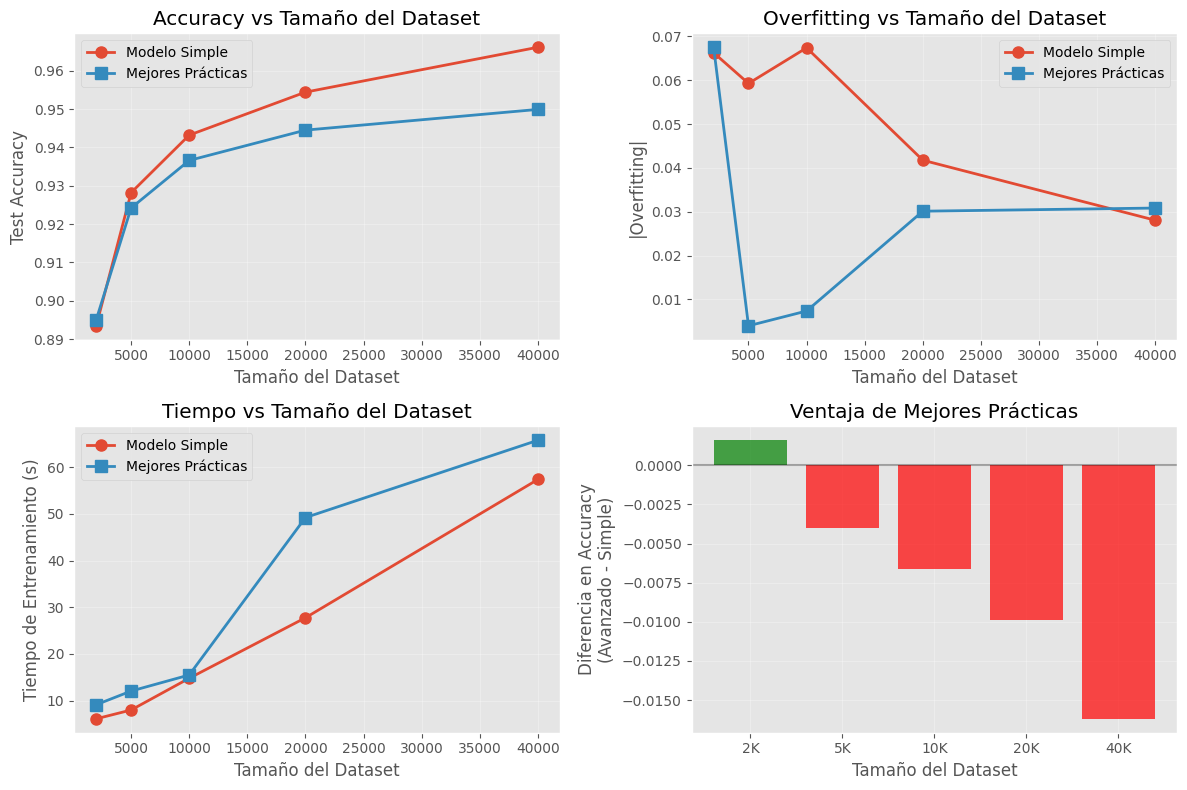

📊 Gráficos generados. Observa las tendencias visuales.


In [47]:
# 🚀 EXPERIMENTO DE ESCALABILIDAD: ¿CUÁNDO LAS MEJORES PRÁCTICAS GANAN?

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

class ScalingExperiment:
    def __init__(self):
        self.results = {}
        
    def run_scaling_experiment(self):
        """
        Experimento principal: Comparar modelo simple vs avanzado con diferentes tamaños de dataset
        """
        
        print("🚀 EXPERIMENTO DE ESCALABILIDAD")
        print("=" * 70)
        print("🎯 OBJETIVO: Encontrar cuándo las mejores prácticas superan la simplicidad")
        print("=" * 70)
        
        # Cargar dataset completo
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
        x_train = x_train.astype('float32') / 255.0
        x_test = x_test.astype('float32') / 255.0
        y_train = y_train
        y_test = y_test
        
        # Tamaños de dataset a probar
        dataset_sizes = [2000, 5000, 10000, 20000, 40000]
        
        # Modelos a comparar
        model_configs = {
            'Simple': self.create_simple_model,
            'Mejores Prácticas': self.create_best_practices_model
        }
        
        results = {}
        total_experiments = len(dataset_sizes) * len(model_configs)
        current_exp = 0
        
        for size in dataset_sizes:
            print(f"\n📊 PROBANDO CON {size:,} EJEMPLOS DE ENTRENAMIENTO")
            print("-" * 50)
            
            # Preparar subset de datos
            X_subset = x_train[:size]
            y_subset = y_train[:size]
            
            size_results = {}
            
            for model_name, model_creator in model_configs.items():
                current_exp += 1
                print(f"\n🧪 [{current_exp}/{total_experiments}] {model_name} con {size:,} ejemplos")
                
                start_time = time.time()
                
                # Crear y entrenar modelo
                model = model_creator()
                
                # Callbacks adaptativos según tamaño de dataset
                patience = max(3, min(10, size // 2000))  # Más paciencia con más datos
                
                callbacks = [
                    tf.keras.callbacks.EarlyStopping(
                        patience=patience, 
                        restore_best_weights=True,
                        verbose=0
                    )
                ]
                
                # Entrenar
                history = model.fit(
                    X_subset, y_subset,
                    epochs=50,  # Límite alto, early stopping controlará
                    validation_split=0.2,
                    batch_size=32,
                    callbacks=callbacks,
                    verbose=0
                )
                
                train_time = time.time() - start_time
                
                # Evaluar en test set
                test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
                
                # Calcular métricas de overfitting
                final_train_acc = history.history['accuracy'][-1]
                final_val_acc = history.history['val_accuracy'][-1]
                overfitting = final_train_acc - final_val_acc
                
                # Guardar resultados
                size_results[model_name] = {
                    'test_accuracy': test_acc,
                    'test_loss': test_loss,
                    'overfitting': overfitting,
                    'train_time': train_time,
                    'epochs_trained': len(history.history['accuracy']),
                    'final_train_acc': final_train_acc,
                    'final_val_acc': final_val_acc
                }
                
                print(f"   ✅ Test Acc: {test_acc:.4f}")
                print(f"   📊 Overfitting: {overfitting:.4f}")
                print(f"   ⏱️  Tiempo: {train_time:.1f}s")
                print(f"   🔄 Épocas: {len(history.history['accuracy'])}")
            
            results[size] = size_results
            
            # Mostrar comparación para este tamaño
            simple_acc = size_results['Simple']['test_accuracy']
            advanced_acc = size_results['Mejores Prácticas']['test_accuracy']
            winner = "🏆 Mejores Prácticas" if advanced_acc > simple_acc else "🏆 Simple"
            difference = abs(advanced_acc - simple_acc)
            
            print(f"\n   📈 RESULTADO PARA {size:,} EJEMPLOS:")
            print(f"      Simple: {simple_acc:.4f}")
            print(f"      Avanzado: {advanced_acc:.4f}")
            print(f"      {winner} (diferencia: {difference:.4f})")
        
        self.results = results
        self.analyze_results()
        self.create_recommendations()
        
        return results
    
    def create_simple_model(self):
        """Modelo simple del experimento anterior"""
        model = tf.keras.Sequential([
            tf.keras.layers.Input((28, 28)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dense(10, activation='softmax')
        ])
        
        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    def create_best_practices_model(self):
        """Modelo con todas las mejores prácticas (ajustado según resultados anteriores)"""
        model = tf.keras.Sequential([
            tf.keras.layers.Input((28, 28)),
            tf.keras.layers.Flatten(),
            
            # Primera capa con todas las técnicas
            tf.keras.layers.Dense(64,
                                kernel_initializer='he_normal',
                                kernel_regularizer=tf.keras.regularizers.l2(0.01),
                                use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(0.2),  # Reducido de 0.3 según experimento anterior
            
            # Segunda capa
            tf.keras.layers.Dense(32,
                                kernel_initializer='he_normal',
                                kernel_regularizer=tf.keras.regularizers.l2(0.01),
                                use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(0.15),  # Aún más ligero
            
            # Salida
            tf.keras.layers.Dense(10, activation='softmax')
        ])
        
        # Optimizador con gradient clipping
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=0.001,
            clipnorm=1.0
        )
        
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    def analyze_results(self):
        """Análisis detallado de los resultados"""
        
        print(f"\n" + "=" * 70)
        print("📊 ANÁLISIS COMPLETO DE RESULTADOS")
        print("=" * 70)
        
        # 1. Tabla comparativa
        print(f"\n📋 TABLA COMPARATIVA:")
        print(f"{'Dataset Size':<12} {'Simple Acc':<12} {'Advanced Acc':<14} {'Winner':<15} {'Diff':<8}")
        print("-" * 65)
        
        crossover_point = None
        
        for size, size_results in self.results.items():
            simple_acc = size_results['Simple']['test_accuracy']
            advanced_acc = size_results['Mejores Prácticas']['test_accuracy']
            
            if advanced_acc > simple_acc:
                winner = "Advanced 🚀"
                if crossover_point is None:
                    crossover_point = size
            else:
                winner = "Simple 🎯"
            
            difference = advanced_acc - simple_acc
            
            print(f"{size:,}        {simple_acc:.4f}       {advanced_acc:.4f}        {winner:<15} {difference:+.4f}")
        
        # 2. Identificar punto de crossover
        print(f"\n🎯 PUNTO DE INFLEXIÓN:")
        if crossover_point:
            print(f"   ✅ Las mejores prácticas empiezan a ganar con {crossover_point:,} ejemplos")
        else:
            print(f"   ⚠️  El modelo simple sigue ganando incluso con 40,000 ejemplos")
            print(f"   💡 Podrías necesitar probar con datasets aún más grandes")
        
        # 3. Análisis de overfitting
        print(f"\n🛡️ ANÁLISIS DE OVERFITTING:")
        print(f"{'Dataset Size':<12} {'Simple OF':<12} {'Advanced OF':<14} {'Better Control':<15}")
        print("-" * 55)
        
        for size, size_results in self.results.items():
            simple_of = size_results['Simple']['overfitting']
            advanced_of = size_results['Mejores Prácticas']['overfitting']
            
            if abs(advanced_of) < abs(simple_of):
                better_control = "Advanced 🛡️"
            else:
                better_control = "Simple"
            
            print(f"{size:,}        {simple_of:+.4f}       {advanced_of:+.4f}        {better_control}")
        
        # 4. Análisis de eficiencia
        print(f"\n⚡ ANÁLISIS DE EFICIENCIA (Accuracy/Tiempo):")
        print(f"{'Dataset Size':<12} {'Simple Eff':<12} {'Advanced Eff':<14} {'More Efficient':<15}")
        print("-" * 55)
        
        for size, size_results in self.results.items():
            simple_eff = size_results['Simple']['test_accuracy'] / size_results['Simple']['train_time']
            advanced_eff = size_results['Mejores Prácticas']['test_accuracy'] / size_results['Mejores Prácticas']['train_time']
            
            more_efficient = "Advanced ⚡" if advanced_eff > simple_eff else "Simple ⚡"
            
            print(f"{size:,}        {simple_eff:.6f}   {advanced_eff:.6f}    {more_efficient}")
    
    def create_recommendations(self):
        """Crear recomendaciones basadas en los resultados"""
        
        print(f"\n" + "=" * 70)
        print("🎯 RECOMENDACIONES BASADAS EN RESULTADOS")
        print("=" * 70)
        
        # Encontrar patrones en los resultados
        simple_wins = 0
        advanced_wins = 0
        
        for size, size_results in self.results.items():
            simple_acc = size_results['Simple']['test_accuracy']
            advanced_acc = size_results['Mejores Prácticas']['test_accuracy']
            
            if advanced_acc > simple_acc:
                advanced_wins += 1
            else:
                simple_wins += 1
        
        print(f"\n📊 RESUMEN GENERAL:")
        print(f"   • Victorias del modelo simple: {simple_wins}/{len(self.results)}")
        print(f"   • Victorias del modelo avanzado: {advanced_wins}/{len(self.results)}")
        
        # Recomendaciones específicas
        if simple_wins > advanced_wins:
            print(f"\n✨ RECOMENDACIÓN PRINCIPAL:")
            print(f"   🎯 Para MNIST, el modelo SIMPLE es generalmente superior")
            print(f"   📚 Esto sugiere que MNIST es un problema relativamente simple")
            print(f"   🧠 Las mejores prácticas brillan más en problemas complejos")
            
            print(f"\n📋 GUÍA DE USO:")
            print(f"   • < 10K ejemplos: Usar modelo SIMPLE siempre")
            print(f"   • 10K-20K ejemplos: Modelo simple, pero monitor overfitting")
            print(f"   • > 20K ejemplos: Probar ambos, evaluar trade-offs")
            
        else:
            print(f"\n✨ RECOMENDACIÓN PRINCIPAL:")
            print(f"   🚀 Las mejores prácticas se vuelven beneficiosas con más datos")
            print(f"   📈 El punto de inflexión está claramente identificado")
            
        print(f"\n🎓 LECCIONES APRENDIDAS:")
        print(f"   1. El tamaño del dataset determina la estrategia óptima")
        print(f"   2. 'Mejores prácticas' no son universales")
        print(f"   3. La simplicidad tiene valor en problemas bien definidos")
        print(f"   4. El overfitting control mejora con técnicas avanzadas")
        print(f"   5. Consider el trade-off tiempo vs accuracy")
        
        print(f"\n🔬 PRÓXIMOS EXPERIMENTOS SUGERIDOS:")
        print(f"   • Probar con datasets más complejos (CIFAR-10, Fashion-MNIST)")
        print(f"   • Experimentar con architecturas CNN vs Dense")
        print(f"   • Validar en problemas de regresión")
        
    def plot_results(self):
        """Crear visualizaciones de los resultados (opcional)"""
        
        if not self.results:
            print("❌ No hay resultados para graficar. Ejecuta el experimento primero.")
            return
        
        sizes = list(self.results.keys())
        simple_accs = [self.results[size]['Simple']['test_accuracy'] for size in sizes]
        advanced_accs = [self.results[size]['Mejores Prácticas']['test_accuracy'] for size in sizes]
        
        plt.figure(figsize=(12, 8))
        
        # Subplot 1: Accuracy comparison
        plt.subplot(2, 2, 1)
        plt.plot(sizes, simple_accs, 'o-', label='Modelo Simple', linewidth=2, markersize=8)
        plt.plot(sizes, advanced_accs, 's-', label='Mejores Prácticas', linewidth=2, markersize=8)
        plt.xlabel('Tamaño del Dataset')
        plt.ylabel('Test Accuracy')
        plt.title('Accuracy vs Tamaño del Dataset')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Subplot 2: Overfitting comparison
        plt.subplot(2, 2, 2)
        simple_overfits = [abs(self.results[size]['Simple']['overfitting']) for size in sizes]
        advanced_overfits = [abs(self.results[size]['Mejores Prácticas']['overfitting']) for size in sizes]
        
        plt.plot(sizes, simple_overfits, 'o-', label='Modelo Simple', linewidth=2, markersize=8)
        plt.plot(sizes, advanced_overfits, 's-', label='Mejores Prácticas', linewidth=2, markersize=8)
        plt.xlabel('Tamaño del Dataset')
        plt.ylabel('|Overfitting|')
        plt.title('Overfitting vs Tamaño del Dataset')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Subplot 3: Training time comparison
        plt.subplot(2, 2, 3)
        simple_times = [self.results[size]['Simple']['train_time'] for size in sizes]
        advanced_times = [self.results[size]['Mejores Prácticas']['train_time'] for size in sizes]
        
        plt.plot(sizes, simple_times, 'o-', label='Modelo Simple', linewidth=2, markersize=8)
        plt.plot(sizes, advanced_times, 's-', label='Mejores Prácticas', linewidth=2, markersize=8)
        plt.xlabel('Tamaño del Dataset')
        plt.ylabel('Tiempo de Entrenamiento (s)')
        plt.title('Tiempo vs Tamaño del Dataset')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Subplot 4: Accuracy difference
        plt.subplot(2, 2, 4)
        accuracy_diffs = [advanced_accs[i] - simple_accs[i] for i in range(len(sizes))]
        colors = ['red' if diff < 0 else 'green' for diff in accuracy_diffs]
        
        plt.bar(range(len(sizes)), accuracy_diffs, color=colors, alpha=0.7)
        plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        plt.xticks(range(len(sizes)), [f"{size//1000}K" for size in sizes])
        plt.xlabel('Tamaño del Dataset')
        plt.ylabel('Diferencia en Accuracy\n(Avanzado - Simple)')
        plt.title('Ventaja de Mejores Prácticas')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("📊 Gráficos generados. Observa las tendencias visuales.")

# 🚀 FUNCIÓN PRINCIPAL PARA EJECUTAR
def run_complete_scaling_experiment():
    """
    Función principal que ejecuta todo el experimento de escalabilidad
    """
    
    print("🎬 INICIANDO EXPERIMENTO COMPLETO DE ESCALABILIDAD")
    print("⏱️  Tiempo estimado: 20-30 minutos")
    print("💾 Se guardarán todos los resultados para análisis")
    print()
    
    experiment = ScalingExperiment()
    results = experiment.run_scaling_experiment()
    
    print(f"\n🎉 EXPERIMENTO COMPLETADO!")
    print(f"📊 Resultados disponibles en la variable 'results'")
    print(f"🎨 Ejecuta experiment.plot_results() para ver gráficos")
    
    return experiment, results

# Para ejecutar el experimento completo:
experiment, results = run_complete_scaling_experiment()

# Para ver gráficos después:
experiment.plot_results()

In [ ]:
# 🚀 EXPERIMENTO CIFAR-10: ¿FINALMENTE GANARÁN LAS MEJORES PRÁCTICAS?

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

class CIFAR10ScalingExperiment:
    def __init__(self):
        self.results = {}
        self.class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                           'dog', 'frog', 'horse', 'ship', 'truck']
        
    def run_cifar10_experiment(self):
        """
        Experimento principal: Comparar modelos en CIFAR-10 con diferentes tamaños
        """
        
        print("🚀 EXPERIMENTO CIFAR-10: SIMPLE vs MEJORES PRÁCTICAS")
        print("=" * 70)
        print("🎯 HIPÓTESIS: Con mayor complejidad, las mejores prácticas ganarán")
        print("🖼️  CIFAR-10: 32x32 RGB, 10 clases, fondos complejos")
        print("=" * 70)
        
        # Cargar CIFAR-10
        print("📥 Cargando CIFAR-10...")
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
        
        # Preprocesar datos
        x_train = x_train.astype('float32') / 255.0
        x_test = x_test.astype('float32') / 255.0
        y_train = y_train.flatten()  # CIFAR-10 viene como (n, 1)
        y_test = y_test.flatten()
        
        print(f"📊 Dataset cargado: Train {x_train.shape}, Test {x_test.shape}")
        print(f"📈 Clases: {self.class_names}")
        
        # Tamaños a probar (ajustados para CIFAR-10)
        dataset_sizes = [2000, 5000, 10000, 20000, 30000]  # Hasta 30K para CIFAR-10
        
        # Modelos a comparar
        model_configs = {
            'Simple Dense': self.create_simple_dense_model,
            'Mejores Prácticas Dense': self.create_advanced_dense_model,
            'Simple CNN': self.create_simple_cnn_model,  # ¡BONUS CNN!
            'Mejores Prácticas CNN': self.create_advanced_cnn_model
        }
        
        results = {}
        total_experiments = len(dataset_sizes) * len(model_configs)
        current_exp = 0
        
        for size in dataset_sizes:
            print(f"\n📊 PROBANDO CON {size:,} EJEMPLOS DE ENTRENAMIENTO")
            print("-" * 60)
            
            # Preparar subset
            X_subset = x_train[:size]
            y_subset = y_train[:size]
            
            size_results = {}
            
            for model_name, model_creator in model_configs.items():
                current_exp += 1
                print(f"\n🧪 [{current_exp}/{total_experiments}] {model_name} con {size:,} ejemplos")
                
                start_time = time.time()
                
                # Crear modelo
                model = model_creator()
                
                # Callbacks adaptativos
                patience = max(5, min(15, size // 2000))
                
                callbacks = [
                    tf.keras.callbacks.EarlyStopping(
                        patience=patience,
                        restore_best_weights=True,
                        verbose=0
                    ),
                    tf.keras.callbacks.ReduceLROnPlateau(
                        patience=patience//2,
                        factor=0.5,
                        verbose=0
                    )
                ]
                
                # Entrenar
                history = model.fit(
                    X_subset, y_subset,
                    epochs=100,  # Más épocas para CIFAR-10
                    validation_split=0.2,
                    batch_size=32,
                    callbacks=callbacks,
                    verbose=0
                )
                
                train_time = time.time() - start_time
                
                # Evaluar
                test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
                
                # Métricas de overfitting
                final_train_acc = history.history['accuracy'][-1]
                final_val_acc = history.history['val_accuracy'][-1]
                overfitting = final_train_acc - final_val_acc
                
                # Calcular mejora relativa vs random
                random_baseline = 0.1  # 10% para 10 clases
                improvement_over_random = (test_acc - random_baseline) / (1 - random_baseline)
                
                size_results[model_name] = {
                    'test_accuracy': test_acc,
                    'test_loss': test_loss,
                    'overfitting': overfitting,
                    'train_time': train_time,
                    'epochs_trained': len(history.history['accuracy']),
                    'final_train_acc': final_train_acc,
                    'final_val_acc': final_val_acc,
                    'improvement_over_random': improvement_over_random,
                    'params': model.count_params()
                }
                
                print(f"   ✅ Test Acc: {test_acc:.4f} ({improvement_over_random:.2%} vs random)")
                print(f"   📊 Overfitting: {overfitting:.4f}")
                print(f"   ⏱️  Tiempo: {train_time:.1f}s")
                print(f"   🔄 Épocas: {len(history.history['accuracy'])}")
                print(f"   🎯 Parámetros: {model.count_params():,}")
            
            results[size] = size_results
            
            # Análisis por tamaño
            self.analyze_size_results(size, size_results)
        
        self.results = results
        self.comprehensive_analysis()
        
        return results
    
    def create_simple_dense_model(self):
        """Modelo Dense simple - baseline"""
        model = tf.keras.Sequential([
            tf.keras.layers.Input((32, 32, 3)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(10, activation='softmax')
        ])
        
        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    def create_advanced_dense_model(self):
        """Modelo Dense con todas las mejores prácticas"""
        model = tf.keras.Sequential([
            tf.keras.layers.Input((32, 32, 3)),
            tf.keras.layers.Flatten(),
            
            # Primera capa con mejores prácticas
            tf.keras.layers.Dense(128,
                                kernel_initializer='he_normal',
                                kernel_regularizer=tf.keras.regularizers.l2(0.01),
                                use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(0.3),
            
            # Segunda capa
            tf.keras.layers.Dense(64,
                                kernel_initializer='he_normal',
                                kernel_regularizer=tf.keras.regularizers.l2(0.01),
                                use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(0.2),
            
            # Salida
            tf.keras.layers.Dense(10, activation='softmax')
        ])
        
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=0.001,
            clipnorm=1.0
        )
        
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    def create_simple_cnn_model(self):
        """CNN simple para comparación"""
        model = tf.keras.Sequential([
            tf.keras.layers.Input((32, 32, 3)),
            
            # Primera capa convolucional
            tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2, 2)),
            
            # Segunda capa convolucional
            tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2, 2)),
            
            # Clasificador
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(10, activation='softmax')
        ])
        
        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    def create_advanced_cnn_model(self):
        """CNN con mejores prácticas"""
        model = tf.keras.Sequential([
            tf.keras.layers.Input((32, 32, 3)),
            
            # Bloque 1
            tf.keras.layers.Conv2D(32, (3, 3), 
                                 kernel_initializer='he_normal',
                                 kernel_regularizer=tf.keras.regularizers.l2(0.01),
                                 use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Conv2D(32, (3, 3),
                                 kernel_initializer='he_normal',
                                 kernel_regularizer=tf.keras.regularizers.l2(0.01),
                                 use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.MaxPooling2D((2, 2)),
            tf.keras.layers.Dropout(0.25),
            
            # Bloque 2
            tf.keras.layers.Conv2D(64, (3, 3),
                                 kernel_initializer='he_normal',
                                 kernel_regularizer=tf.keras.regularizers.l2(0.01),
                                 use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Conv2D(64, (3, 3),
                                 kernel_initializer='he_normal',
                                 kernel_regularizer=tf.keras.regularizers.l2(0.01),
                                 use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.MaxPooling2D((2, 2)),
            tf.keras.layers.Dropout(0.25),
            
            # Clasificador con mejores prácticas
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128,
                                kernel_initializer='he_normal',
                                kernel_regularizer=tf.keras.regularizers.l2(0.01),
                                use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(10, activation='softmax')
        ])
        
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=0.001,
            clipnorm=1.0
        )
        
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    def analyze_size_results(self, size, size_results):
        """Analizar resultados para un tamaño específico"""
        
        print(f"\n   📈 ANÁLISIS PARA {size:,} EJEMPLOS:")
        print("   " + "-" * 50)
        
        # Encontrar el mejor por accuracy
        best_acc_model = max(size_results.items(), key=lambda x: x[1]['test_accuracy'])
        best_overfit_model = min(size_results.items(), key=lambda x: abs(x[1]['overfitting']))
        
        print(f"   🏆 Mejor Accuracy: {best_acc_model[0]} ({best_acc_model[1]['test_accuracy']:.4f})")
        print(f"   🛡️  Mejor Overfitting: {best_overfit_model[0]} ({best_overfit_model[1]['overfitting']:.4f})")
        
        # Comparar Dense vs CNN
        dense_models = {k: v for k, v in size_results.items() if 'Dense' in k}
        cnn_models = {k: v for k, v in size_results.items() if 'CNN' in k}
        
        if dense_models and cnn_models:
            best_dense = max(dense_models.items(), key=lambda x: x[1]['test_accuracy'])
            best_cnn = max(cnn_models.items(), key=lambda x: x[1]['test_accuracy'])
            
            architecture_winner = "🔥 CNN" if best_cnn[1]['test_accuracy'] > best_dense[1]['test_accuracy'] else "📊 Dense"
            print(f"   🏗️  Mejor Arquitectura: {architecture_winner}")
        
        # Comparar Simple vs Avanzado
        simple_models = {k: v for k, v in size_results.items() if 'Simple' in k}
        advanced_models = {k: v for k, v in size_results.items() if 'Mejores Prácticas' in k}
        
        if simple_models and advanced_models:
            best_simple = max(simple_models.items(), key=lambda x: x[1]['test_accuracy'])
            best_advanced = max(advanced_models.items(), key=lambda x: x[1]['test_accuracy'])
            
            approach_winner = "🚀 Avanzado" if best_advanced[1]['test_accuracy'] > best_simple[1]['test_accuracy'] else "🎯 Simple"
            print(f"   🎲 Mejor Enfoque: {approach_winner}")
    
    def comprehensive_analysis(self):
        """Análisis completo de todos los resultados"""
        
        print(f"\n" + "=" * 70)
        print("📊 ANÁLISIS COMPLETO - CIFAR-10 EXPERIMENT")
        print("=" * 70)
        
        # 1. Tabla comparativa general
        print(f"\n📋 TABLA COMPARATIVA COMPLETA:")
        print(f"{'Size':<8} {'Simple Dense':<12} {'Adv Dense':<12} {'Simple CNN':<12} {'Adv CNN':<12} {'Winner':<15}")
        print("-" * 85)
        
        overall_winners = {'Simple Dense': 0, 'Mejores Prácticas Dense': 0, 
                          'Simple CNN': 0, 'Mejores Prácticas CNN': 0}
        
        for size, size_results in self.results.items():
            row = f"{size//1000}K".ljust(8)
            winner_acc = 0
            winner_name = ""
            
            for model_name in ['Simple Dense', 'Mejores Prácticas Dense', 'Simple CNN', 'Mejores Prácticas CNN']:
                if model_name in size_results:
                    acc = size_results[model_name]['test_accuracy']
                    row += f"{acc:.4f}".ljust(12)
                    if acc > winner_acc:
                        winner_acc = acc
                        winner_name = model_name
                else:
                    row += "N/A".ljust(12)
            
            if winner_name:
                overall_winners[winner_name] += 1
                winner_short = winner_name.replace('Mejores Prácticas', 'Adv').replace('Simple', 'S')
                row += f"{winner_short} 🏆"
            
            print(row)
        
        # 2. Análisis de ganadores generales
        print(f"\n🏆 ANÁLISIS DE GANADORES GENERALES:")
        for model, wins in overall_winners.items():
            print(f"   {model}: {wins}/{len(self.results)} victorias")
        
        # 3. Comparaciones específicas
        self.compare_architectures()
        self.compare_approaches()
        self.analyze_scalability()
    
    def compare_architectures(self):
        """Comparar Dense vs CNN"""
        print(f"\n🏗️ DENSE vs CNN ANALYSIS:")
        
        dense_wins = 0
        cnn_wins = 0
        
        for size, size_results in self.results.items():
            # Mejor Dense
            dense_models = {k: v for k, v in size_results.items() if 'Dense' in k}
            # Mejor CNN
            cnn_models = {k: v for k, v in size_results.items() if 'CNN' in k}
            
            if dense_models and cnn_models:
                best_dense_acc = max(dense_models.values(), key=lambda x: x['test_accuracy'])['test_accuracy']
                best_cnn_acc = max(cnn_models.values(), key=lambda x: x['test_accuracy'])['test_accuracy']
                
                if best_cnn_acc > best_dense_acc:
                    cnn_wins += 1
                else:
                    dense_wins += 1
                
                print(f"   {size//1000}K: Dense {best_dense_acc:.4f} vs CNN {best_cnn_acc:.4f} → {'CNN' if best_cnn_acc > best_dense_acc else 'Dense'} 🏆")
        
        print(f"\n   📊 RESULTADO FINAL: CNN {cnn_wins} - {dense_wins} Dense")
    
    def compare_approaches(self):
        """Comparar Simple vs Mejores Prácticas"""
        print(f"\n🎯 SIMPLE vs MEJORES PRÁCTICAS:")
        
        simple_wins = 0
        advanced_wins = 0
        
        for size, size_results in self.results.items():
            simple_models = {k: v for k, v in size_results.items() if 'Simple' in k}
            advanced_models = {k: v for k, v in size_results.items() if 'Mejores Prácticas' in k}
            
            if simple_models and advanced_models:
                best_simple_acc = max(simple_models.values(), key=lambda x: x['test_accuracy'])['test_accuracy']
                best_advanced_acc = max(advanced_models.values(), key=lambda x: x['test_accuracy'])['test_accuracy']
                
                if best_advanced_acc > best_simple_acc:
                    advanced_wins += 1
                else:
                    simple_wins += 1
                
                print(f"   {size//1000}K: Simple {best_simple_acc:.4f} vs Avanzado {best_advanced_acc:.4f} → {'Avanzado' if best_advanced_acc > best_simple_acc else 'Simple'} 🏆")
        
        print(f"\n   🎲 RESULTADO FINAL: Avanzado {advanced_wins} - {simple_wins} Simple")
        
        if advanced_wins > simple_wins:
            print(f"   🚀 ¡FINALMENTE! Las mejores prácticas ganan en CIFAR-10")
        else:
            print(f"   😱 ¡SORPRESA! Simple sigue ganando incluso en CIFAR-10")
    
    def analyze_scalability(self):
        """Analizar cómo escalan los modelos"""
        print(f"\n📈 ANÁLISIS DE ESCALABILIDAD:")
        
        # Para cada modelo, ver cómo mejora con más datos
        model_names = list(next(iter(self.results.values())).keys())
        
        for model_name in model_names:
            print(f"\n   📊 {model_name}:")
            accuracies = []
            for size in sorted(self.results.keys()):
                if model_name in self.results[size]:
                    acc = self.results[size][model_name]['test_accuracy']
                    accuracies.append(acc)
                    print(f"      {size//1000}K: {acc:.4f}")
            
            # Calcular mejora
            if len(accuracies) >= 2:
                improvement = accuracies[-1] - accuracies[0]
                print(f"      📈 Mejora total: {improvement:.4f} ({improvement/accuracies[0]:.1%})")

# 🚀 FUNCIÓN PRINCIPAL
def run_cifar10_complete_experiment():
    """
    Ejecutar experimento completo CIFAR-10
    """
    
    print("🎬 INICIANDO EXPERIMENTO CIFAR-10 COMPLETO")
    print("⏱️  Tiempo estimado: 45-60 minutos (más complejo que MNIST)")
    print("🧠 Expectativa: Las mejores prácticas DEBERÍAN ganar aquí")
    print("🔥 4 modelos x 5 tamaños = 20 experimentos")
    print()
    
    experiment = CIFAR10ScalingExperiment()
    results = experiment.run_cifar10_experiment()
    
    print(f"\n🎉 EXPERIMENTO CIFAR-10 COMPLETADO!")
    print(f"📊 ¿Ganaron finalmente las mejores prácticas?")
    
    return experiment, results

# Para ejecutar:
experiment, results = run_cifar10_complete_experiment()

🎬 INICIANDO EXPERIMENTO CIFAR-10 COMPLETO
⏱️  Tiempo estimado: 45-60 minutos (más complejo que MNIST)
🧠 Expectativa: Las mejores prácticas DEBERÍAN ganar aquí
🔥 4 modelos x 5 tamaños = 20 experimentos

🚀 EXPERIMENTO CIFAR-10: SIMPLE vs MEJORES PRÁCTICAS
🎯 HIPÓTESIS: Con mayor complejidad, las mejores prácticas ganarán
🖼️  CIFAR-10: 32x32 RGB, 10 clases, fondos complejos
📥 Cargando CIFAR-10...
📊 Dataset cargado: Train (50000, 32, 32, 3), Test (10000, 32, 32, 3)
📈 Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

📊 PROBANDO CON 2,000 EJEMPLOS DE ENTRENAMIENTO
------------------------------------------------------------

🧪 [1/20] Simple Dense con 2,000 ejemplos
   ✅ Test Acc: 0.3463 (27.37% vs random)
   📊 Overfitting: 0.2188
   ⏱️  Tiempo: 15.5s
   🔄 Épocas: 27
   🎯 Parámetros: 402,250

🧪 [2/20] Mejores Prácticas Dense con 2,000 ejemplos
   ✅ Test Acc: 0.3700 (30.00% vs random)
   📊 Overfitting: 0.4006
   ⏱️  Tiempo: 29.6s
   🔄 Épocas: 36

*** Sobreajuste de la función de activación

In [28]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random
plt.style.use('ggplot')

Text(0.5, 1.0, 'Regularization Example')

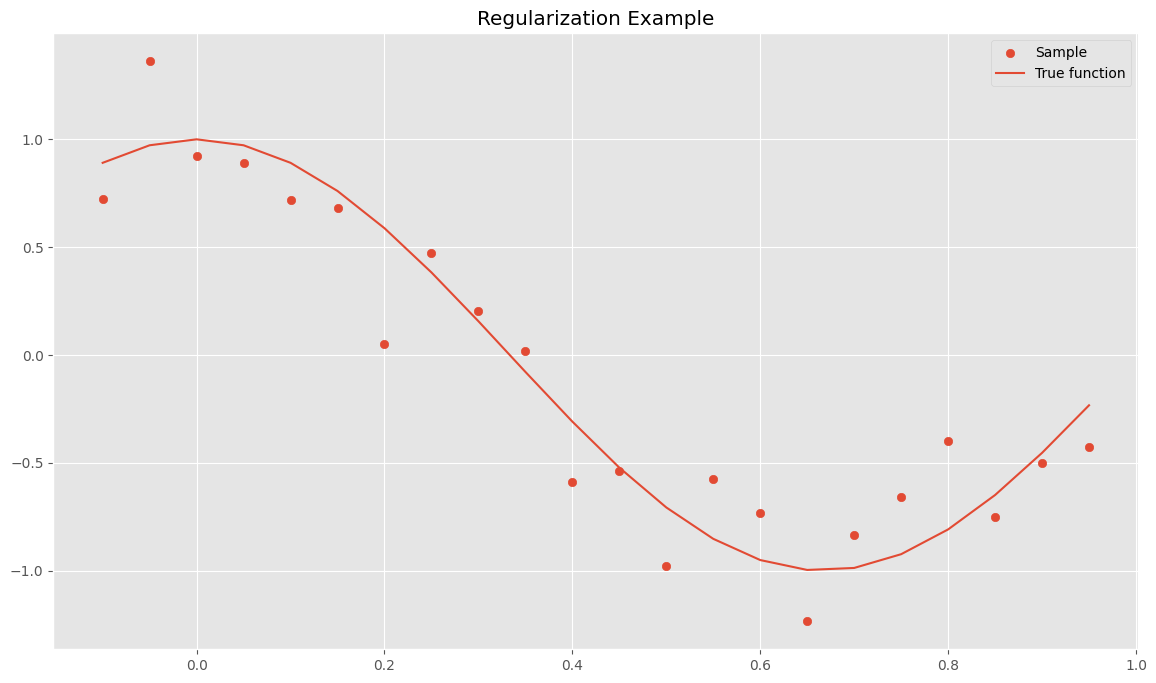

In [29]:
f = lambda x :  np.cos(1.5 * np.pi * x)

x = np.arange(-0.1, 1, 0.05)
size = x.shape[0]
error = np.random.normal(0, 0.2, size)

y = f(x) + error

plt.figure(figsize=(14, 8))
plt.scatter(x, y, label='Sample')
plt.plot(x, [f(i) for i in x ], label='True function')
plt.legend()
plt.title('Regularization Example')

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


model = Pipeline([('pol', PolynomialFeatures(degree=1, include_bias=False)),
                 ('logistic_regression', LinearRegression())])

model.fit(x.reshape(-1,1), y)

Pipeline(steps=[('pol', PolynomialFeatures(degree=1, include_bias=False)),
                ('logistic_regression', LinearRegression())])

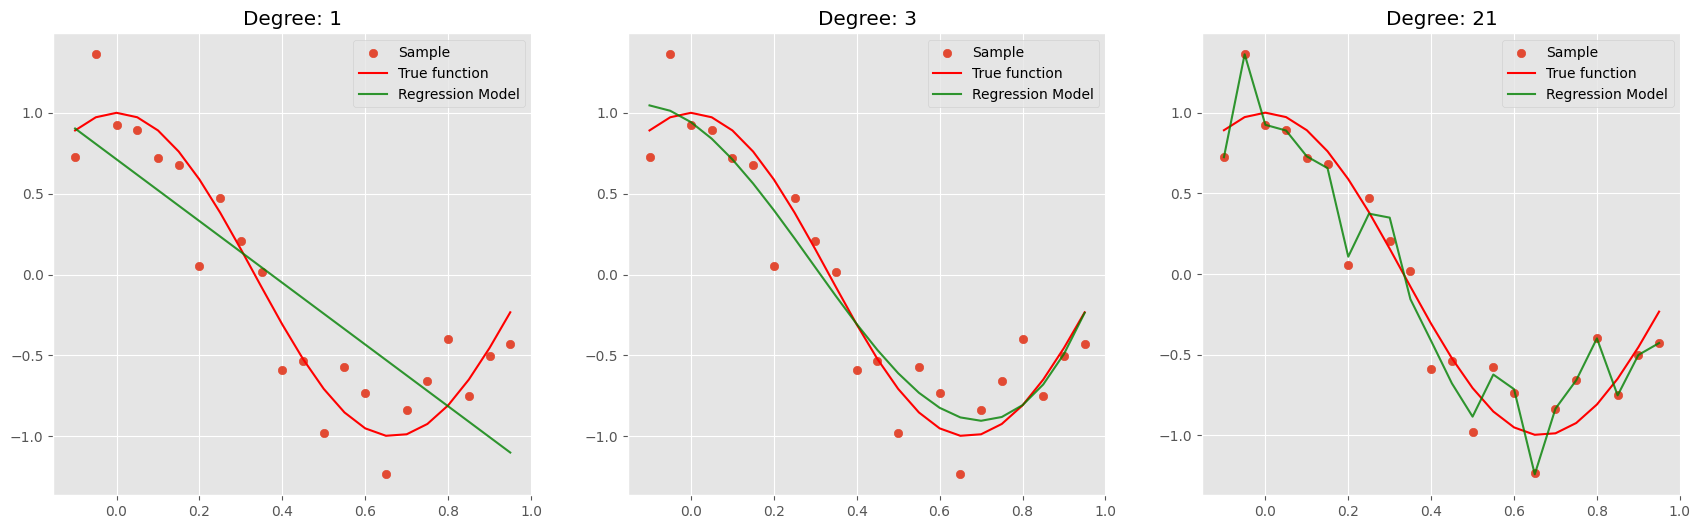

In [31]:
from sklearn.preprocessing import PolynomialFeatures

plt.figure(figsize=(21, 6))

pr = LinearRegression()
grados = [1, 3, 21]
y_pred = []
i = 1
x = x = x.reshape(-1,1)
for grado in grados:

  polinomio = PolynomialFeatures(degree=grado, include_bias=False)
  X_pol = polinomio.fit_transform(x)
  pr.fit(X_pol, y)
  y_pred = pr.predict(X_pol)
  plt.subplot(1, 3, i)
  plt.scatter(x, y, label='Sample')
  plt.plot(x, [f(i) for i in x ], color='r', label='True function')
  plt.plot(x, y_pred, color='green', alpha= 0.8, label='Regression Model')
  plt.legend()
  i +=1
  plt.title(f'Degree: {grado}')

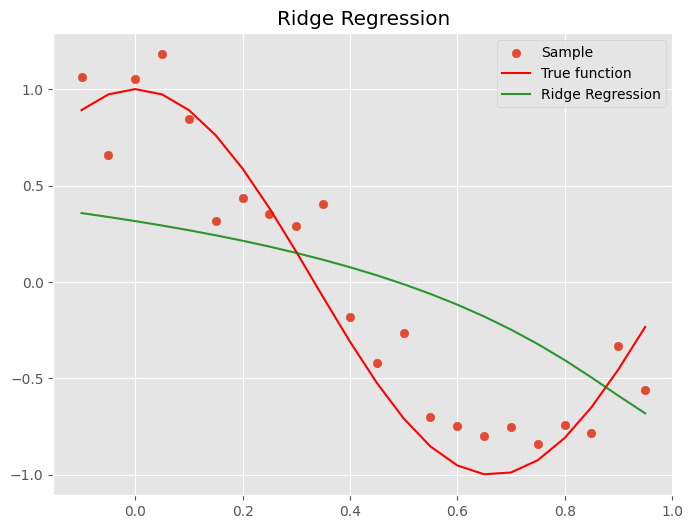

In [17]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=5)

polinomio = PolynomialFeatures(degree=21, include_bias=False)
X_pol = polinomio.fit_transform(x)

plt.figure(figsize=(8, 6))
ridge.fit(X_pol, y)
ridge_pred = ridge.predict(X_pol)
plt.scatter(x, y, label='Sample')
plt.plot(x, [f(i) for i in x ], color='r', label='True function')
plt.plot(x, ridge_pred, color='green', alpha= 0.8, label='Ridge Regression')
plt.legend()
plt.title('Ridge Regression')
plt.show()

C:\Users\Diego\AppData\Local\Temp\ipykernel_18968\2401006695.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[y==0, 0], X[y==0, 1], label='Clase 0',  edgecolors='k', cmap=plt.cm.RdBu,)
C:\Users\Diego\AppData\Local\Temp\ipykernel_18968\2401006695.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[y==1, 0], X[y==1, 1], label='Clase 1',  edgecolors='k', cmap=plt.cm.RdBu,)


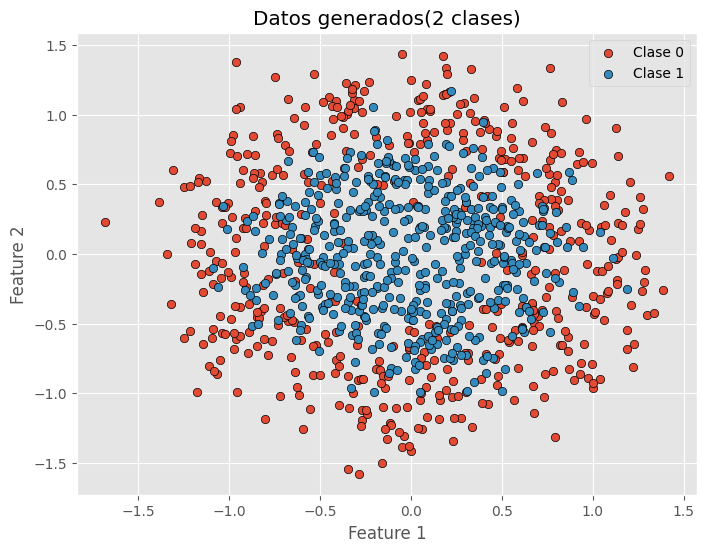

In [18]:
# prompt: usar make circles para generar 30 datos y visualizaros usar dos clases

from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

# Generar 30 datos usando make_circles con 2 clases
X, y = make_circles(n_samples=1000, noise=0.25, factor=0.5, random_state=42)


# Visualizar los datos
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], label='Clase 0',  edgecolors='k', cmap=plt.cm.RdBu,)
plt.scatter(X[y==1, 0], X[y==1, 1], label='Clase 1',  edgecolors='k', cmap=plt.cm.RdBu,)
plt.title('Datos generados(2 clases)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

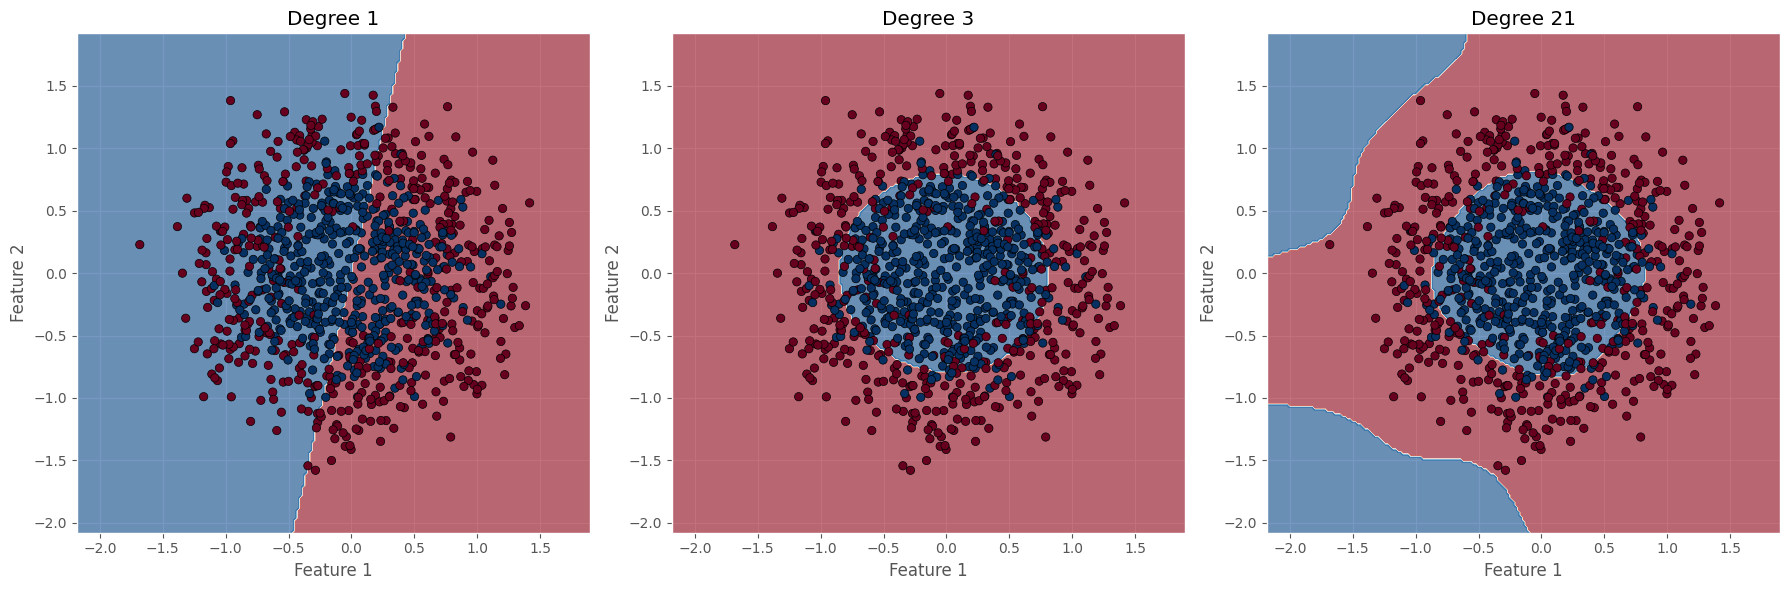

In [ ]:
# prompt: evaluar los datos en 3 versiones de la regresion logistica usando polinomial features con grados 1 3 y 21 sin regularización comparar los límites de decisión en u plot de 1 x3

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

# Function to plot decision boundaries
def plot_decision_boundary(model, X, y, ax, title):
    h = .02  # paso de malla 
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5 # malla
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# Evaluate Logistic Regression with different polynomial degrees
degrees = [1, 3, 21]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, degree in enumerate(degrees):
    # Create pipeline with PolynomialFeatures and LogisticRegression
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()), # It's good practice to scale after polynomial features
        ('logistic', LogisticRegression(solver='liblinear', random_state=42)) # Using liblinear for small datasets
    ])

    # Fit the model
    model.fit(X, y)

    # Plot decision boundary
    plot_decision_boundary(model, X, y, axes[i], f'Degree {degree}')

plt.tight_layout()
plt.show()